# Un script permettant de calculer des carte de likelihood pour des réseaux pré-entrainés sur Imagenet et testés sur le dataset Animal 10k


In [1]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.1.2+cu118
---------------------------------------------------------------------------------------------------
Welcome on Windows-10-10.0.19045-SP0
Random seed 1998 has been set.


In [2]:
# The dataset to import images from

data_set_type = 'animal_10k'
args = Params()
args.root = f'{DATAROOT}/{data_set_type}/ap-10k/' # Directory containing images
args.folders = ['animal_data'] # type of images to use

args.do_saccade = True
args.do_resize = False
args.do_mask = False

In [ ]:
pos_pred_zero = ((args.resolution[0]*args.resolution[1])//2)
print('lets go')
for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        for do_polar in [False, True]:
            do_polar = do_polar if model_data_set_type != 'raw' else False
            args.do_polar = do_polar
            print(f'{args.do_polar=}')

            image_datasets = image_datasets_transforms(args, shuffle=False, verbose=False)
        
            print(50*'.')
            
            model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '.pt' if model_data_set_type != 'raw' else None
            
            model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

            annotations = get_annotation('animal')

            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_map_Animal_10k_paper.parquet'
            print(df_filename)
            df_map = None
            
            with torch.no_grad():
                for i_image, (images, label) in tqdm(enumerate(image_datasets)):
                
                    image_name = image_datasets.imgs[i_image][0].split('/')[-1]
                    
                    ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Animal10k')
            
            
                    if ground_true.min() == 0.0:
                        since = time.time()
                        
                        images = images.to(device, non_blocking=True)
                        
                        heat_map = model(images)
        
        
                        _, pred_zero = torch.max(heat_map[pos_pred_zero].data, 0) # get the predicted 
                        
                        sum = 1 if torch.argmax(torch.sum(heat_map, dim=0)).item() in match['animal'] else 0

                        heatmap_soft = torch.nn.functional.softmax(heat_map, dim=1)

                        likelihood_zero = torch.max(heatmap_soft[pos_pred_zero].data).item()
                        
                        heatmap_prior = torch.sum(heatmap_soft[:,match['animal']], dim=1)

                    
                        mid_point, in_point, ext_point = get_like_point(heatmap_prior, args.resolution, three_points)
    
                        arg_max_prior = torch.argmax(heatmap_prior)
                        position_prior = (arg_max_prior.item()%args.resolution[0], arg_max_prior.item()//args.resolution[1])
                        pov_max_prior = heat_map[arg_max_prior]
                        _, pred_prior = torch.max(pov_max_prior.data, 0)
                        likelihood_prior = torch.max(heatmap_prior).item()

                        arg_min_prior = torch.argmin(heatmap_prior)
                        position_min = (arg_min_prior.item()%args.resolution[0], arg_min_prior.item()//args.resolution[1])
                        _, pred_prior_min = torch.max(heat_map[arg_min_prior].data, 0) # pred at pov_min_prior
                        likelihood_prior_min = torch.min(heatmap_prior).item()

                        midle_points = get_points_between(position_prior, position_min)
                        
                        midle_point = midle_points[len(midle_points)//2]
                        arg_mid_prior = (midle_point[0]*args.resolution[0])+midle_point[1]
                        _, pred_prior_mid = torch.max(heat_map[arg_mid_prior].data, 0) # pred at pov_mid_prior
                        likelihood_prior_mid = heatmap_prior[arg_mid_prior].item()
                    
    
                        arg_max_no_prior = torch.argmax(heatmap_soft)
                        pred_no_prior = (arg_max_no_prior%1000)
                        likelihood_no_prior = heatmap_soft[(arg_max_no_prior//1000), pred_no_prior].item()
                        
                        
                        out_heat = th_delete(heatmap_prior, ground_true_indices[0])
                        
                        likelihood_out_max = torch.max(out_heat).item()
                        likelihood_in_max = torch.max(heatmap_prior[ground_true_indices[0]]).item()
    
                        likelihood_out_mean = torch.mean(out_heat).item()
                        likelihood_in_mean = torch.mean(heatmap_prior[ground_true_indices[0]]).item()
                        
                    
        
                        Iou = get_IoU(heatmap_prior.cpu(), ground_true.reshape(args.resolution[0]*args.resolution[1]))
                    
                        PG = 1 if likelihood_in_max > likelihood_out_max else 0

                        dist = [euclidean_distance(position_prior, midle_point), euclidean_distance(midle_point, position_min)]
                        dist[1] += dist[0]
                        
                        pred_zero = 1 if pred_zero.item() in match['animal'] else 0
                        pred_prior = 1 if pred_prior.item() in match['animal'] else 0
                        pred_no_prior = 1 if pred_no_prior.item() in match['animal'] else 0
                        pred_prior_mid = 1 if pred_prior_mid.item() in match['animal'] else 0
                        pred_prior_min = 1 if pred_prior_min.item() in match['animal'] else 0

                        
                        df_map_ = pd.DataFrame({'ImageId':image_name, 'likelihood_in_max': likelihood_in_max, 'likelihood_out_max': likelihood_out_max, 'pred_prior_min':pred_prior_min,
                                                                     'pred_zero':pred_zero, 'pred_prior':pred_prior, 'pred_no_prior':pred_no_prior, 'pred_prior_mid':pred_prior_mid,
                                                                     'likelihood_prior':likelihood_prior, 'likelihood_zero':likelihood_zero, 'likelihood_no_prior':likelihood_no_prior,
                                                                     'likelihood_out_mean': likelihood_out_mean, 'likelihood_in_mean': likelihood_in_mean,
                                                                     'mid_point':mid_point.item(), 'in_point':in_point.item(), 'ext_point':ext_point.item(), 'Iou': [Iou],  'likelihood_prior_mid':likelihood_prior_mid,
                                                                     'position_prior':[position_prior], 'position_min':[position_min], 'midle_point':[midle_point], 'likelihood_prior_min':likelihood_prior_min, 
                                                                         'sum':sum, 'time':time.time() - since, 'PG':PG, 'Distance_0': [dist[0]], 'Distance_1': [dist[1]]})
                        df_map = store_pandas(df_map, df_map_)
            df_map.to_parquet(df_filename)
            


In [3]:
def get_pandas(model_data_set_type, model_name):
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, True) + f'_map_Animal_10k_paper.parquet'

    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df_ret = pd.read_parquet(df_filename)


    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + f'_map_Animal_10k_paper.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)

    df_filename = get_filename(data_cache, datetag, 'raw', model_name, False) + f'_map_Animal_10k_paper.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df_raw = pd.read_parquet(df_filename)
    
        
    return df, df_ret, df_raw

model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_Animal_10k_paper.parquet'


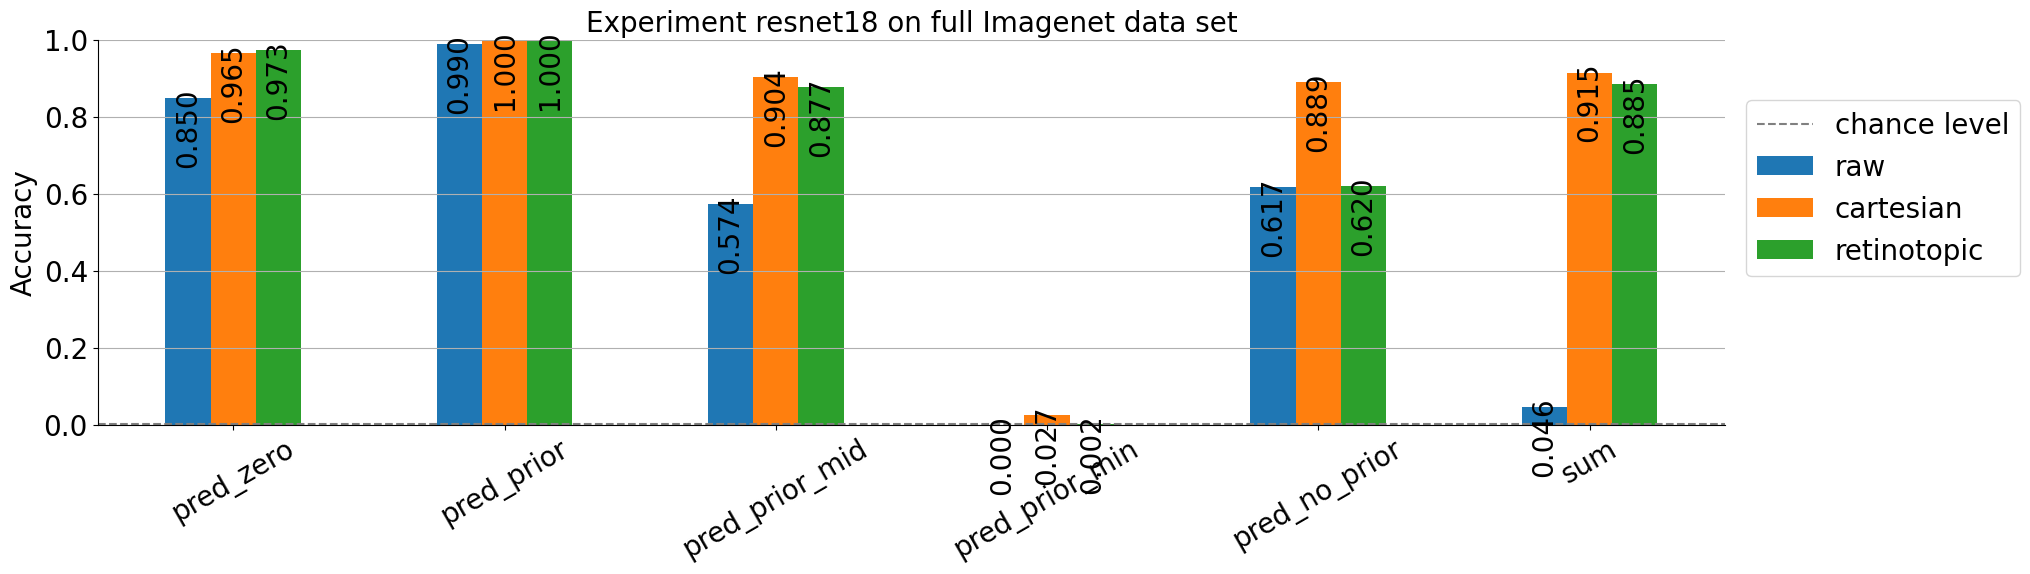

..................................................
df_filename='cached_data/2024-05-24_full_resnet50_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_Animal_10k_paper.parquet'


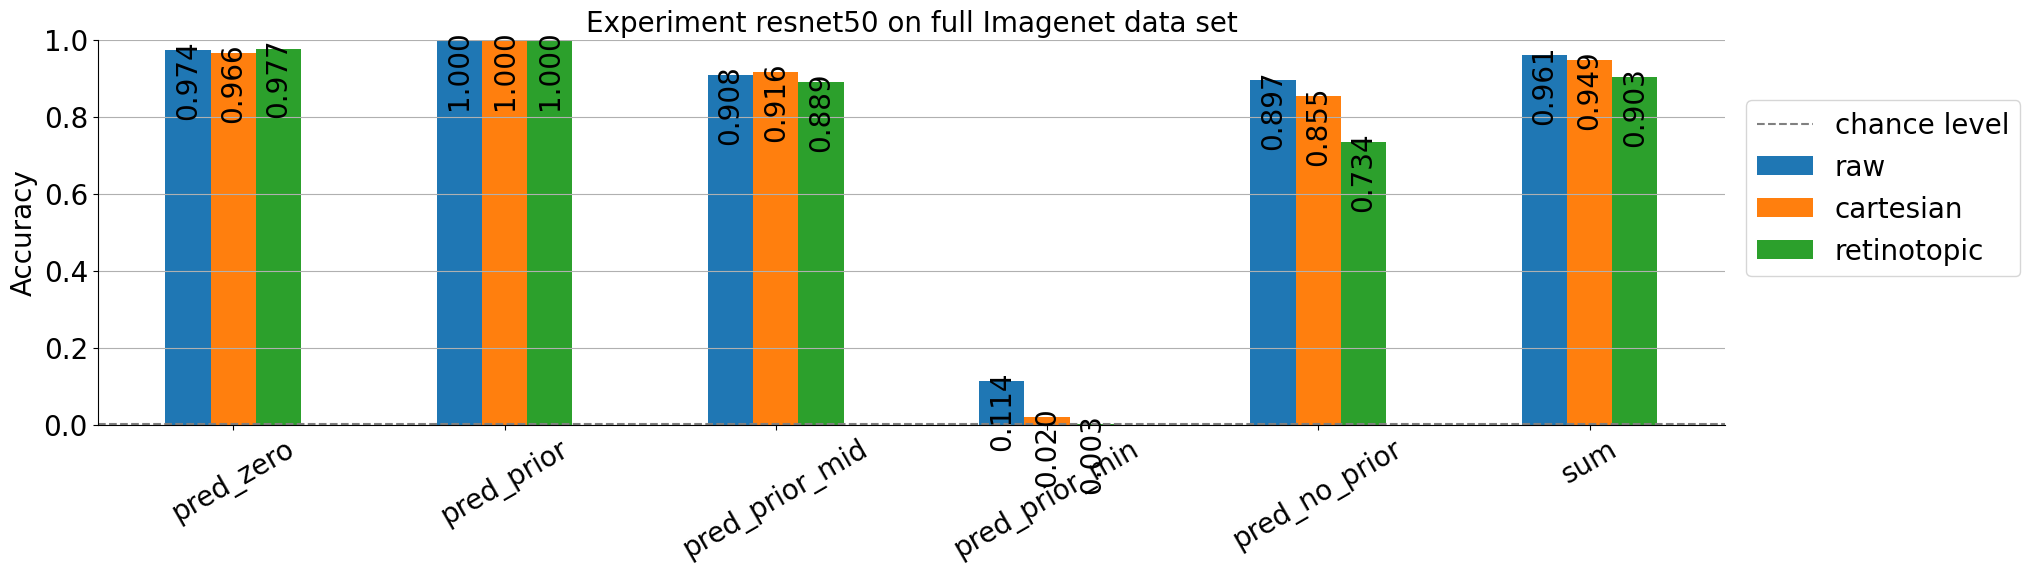

..................................................
df_filename='cached_data/2024-05-24_full_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_Animal_10k_paper.parquet'


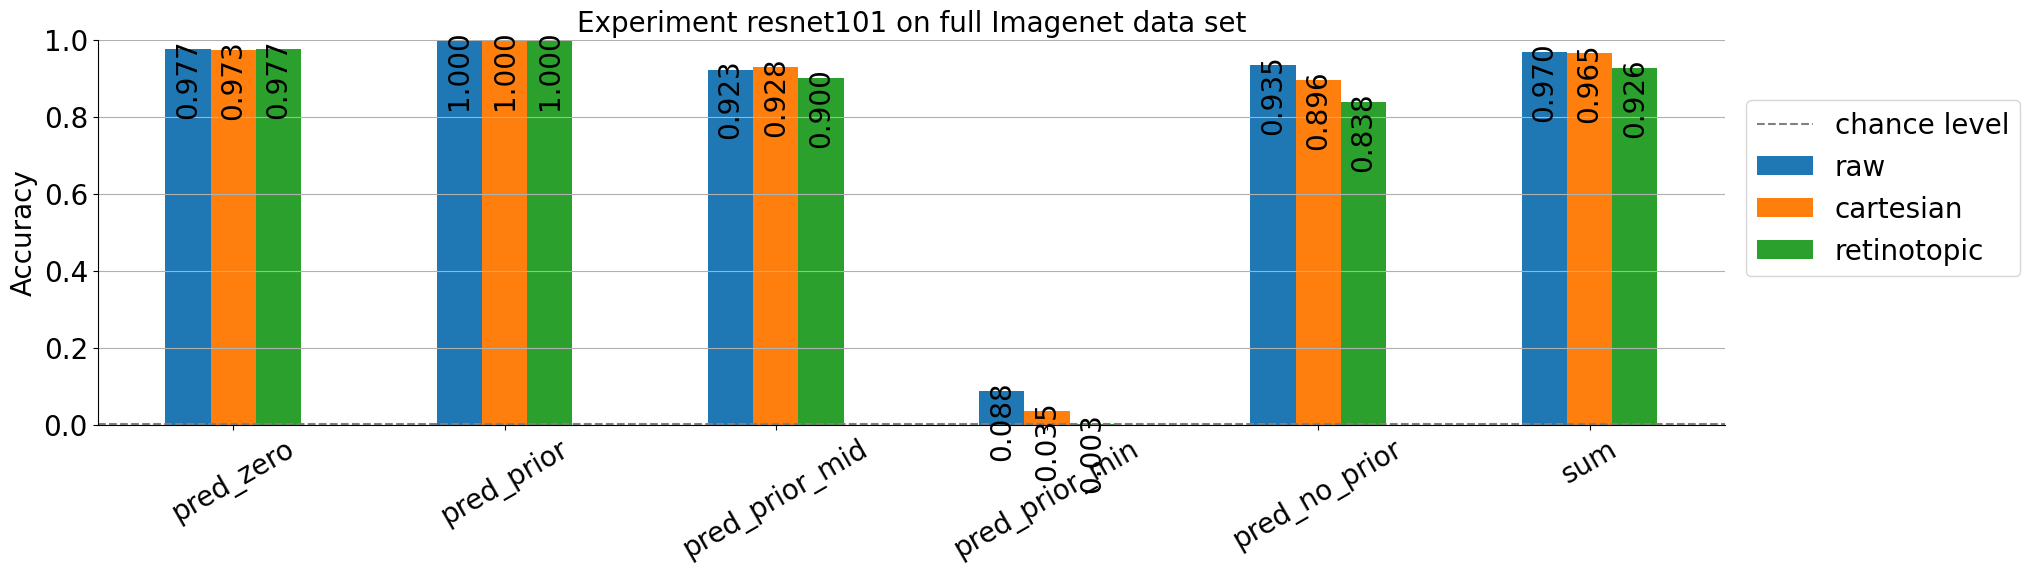

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet18_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet18_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_Animal_10k_paper.parquet'


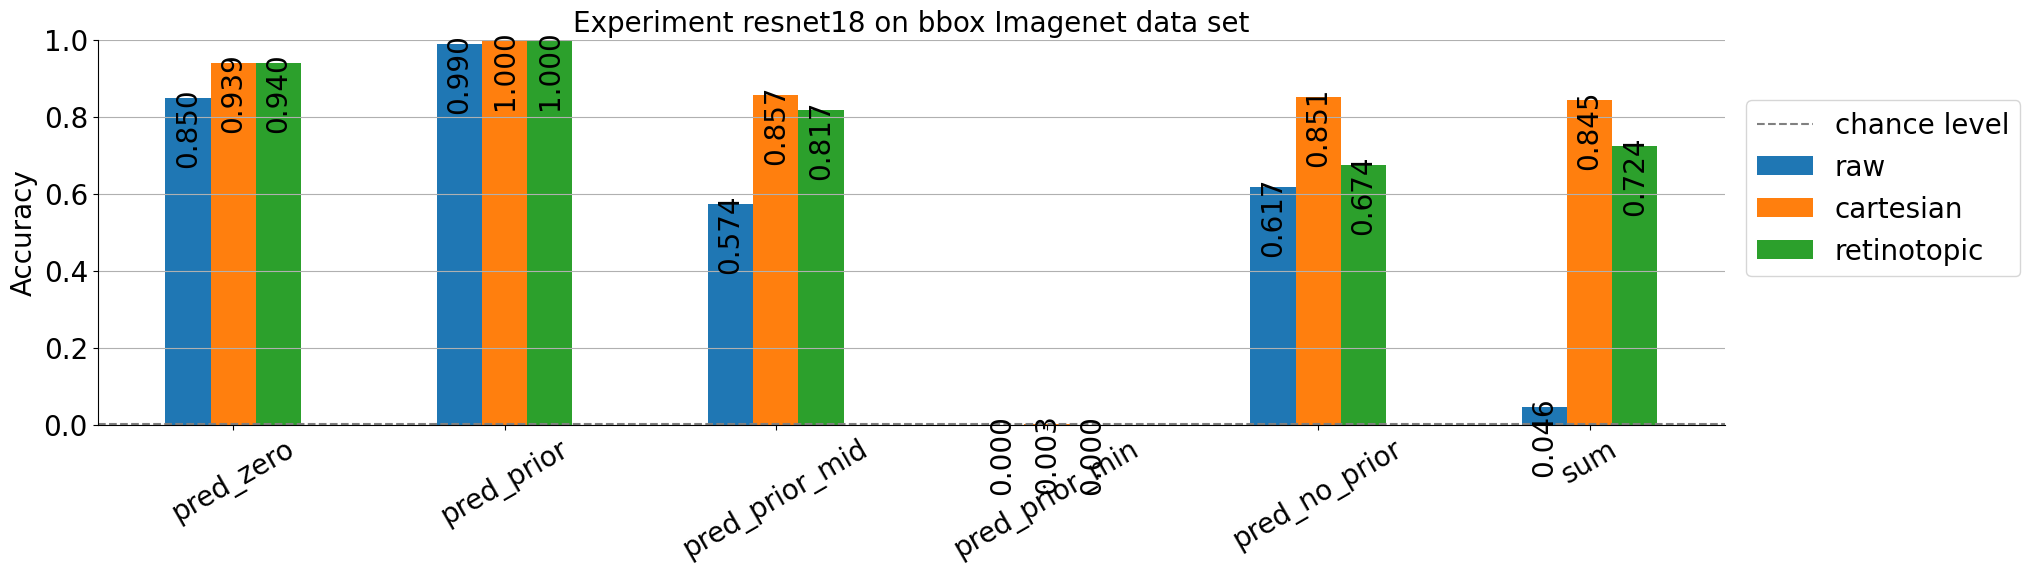

..................................................
df_filename='cached_data/2024-05-24_bbox_resnet50_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet50_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_Animal_10k_paper.parquet'


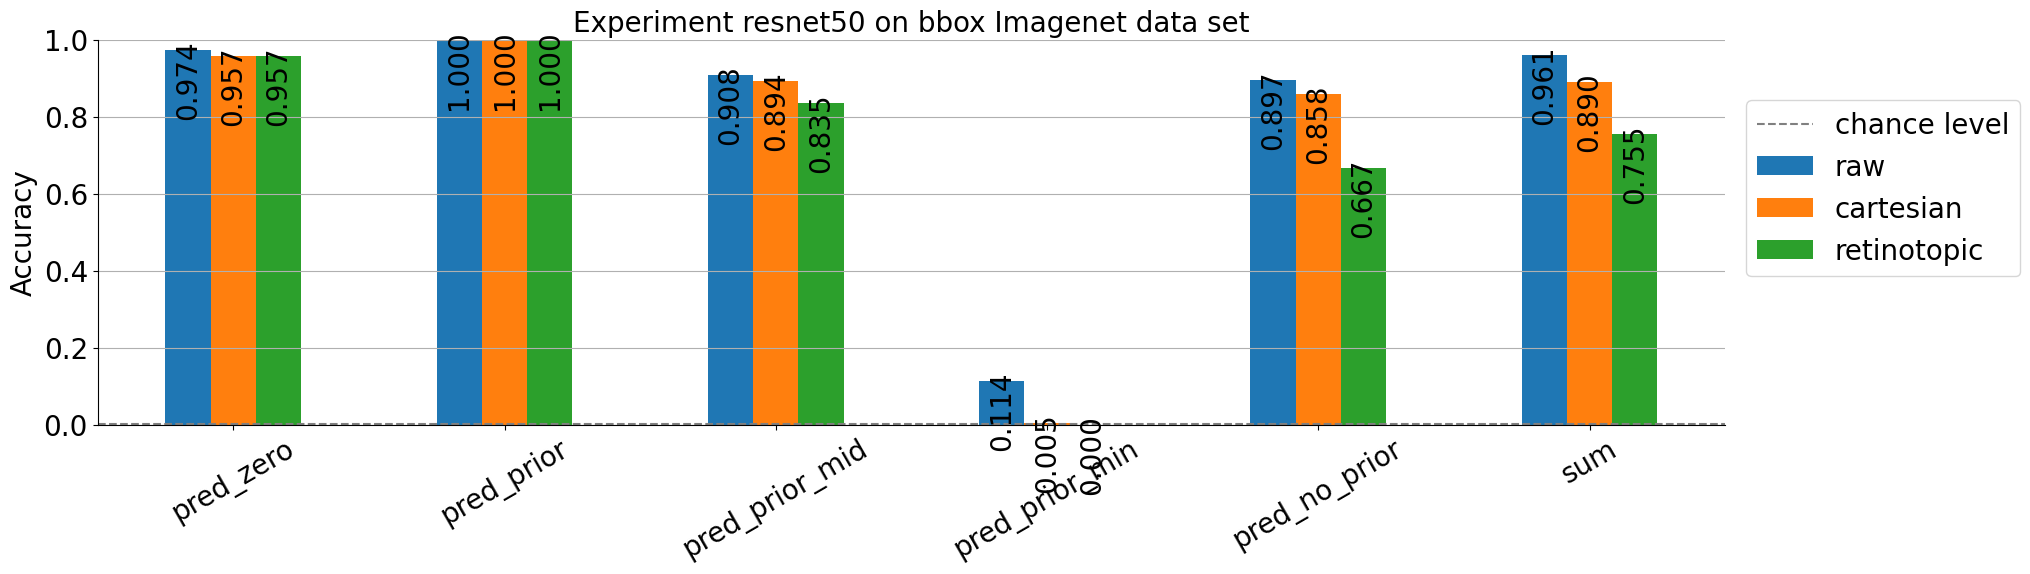

..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_Animal_10k_paper.parquet'


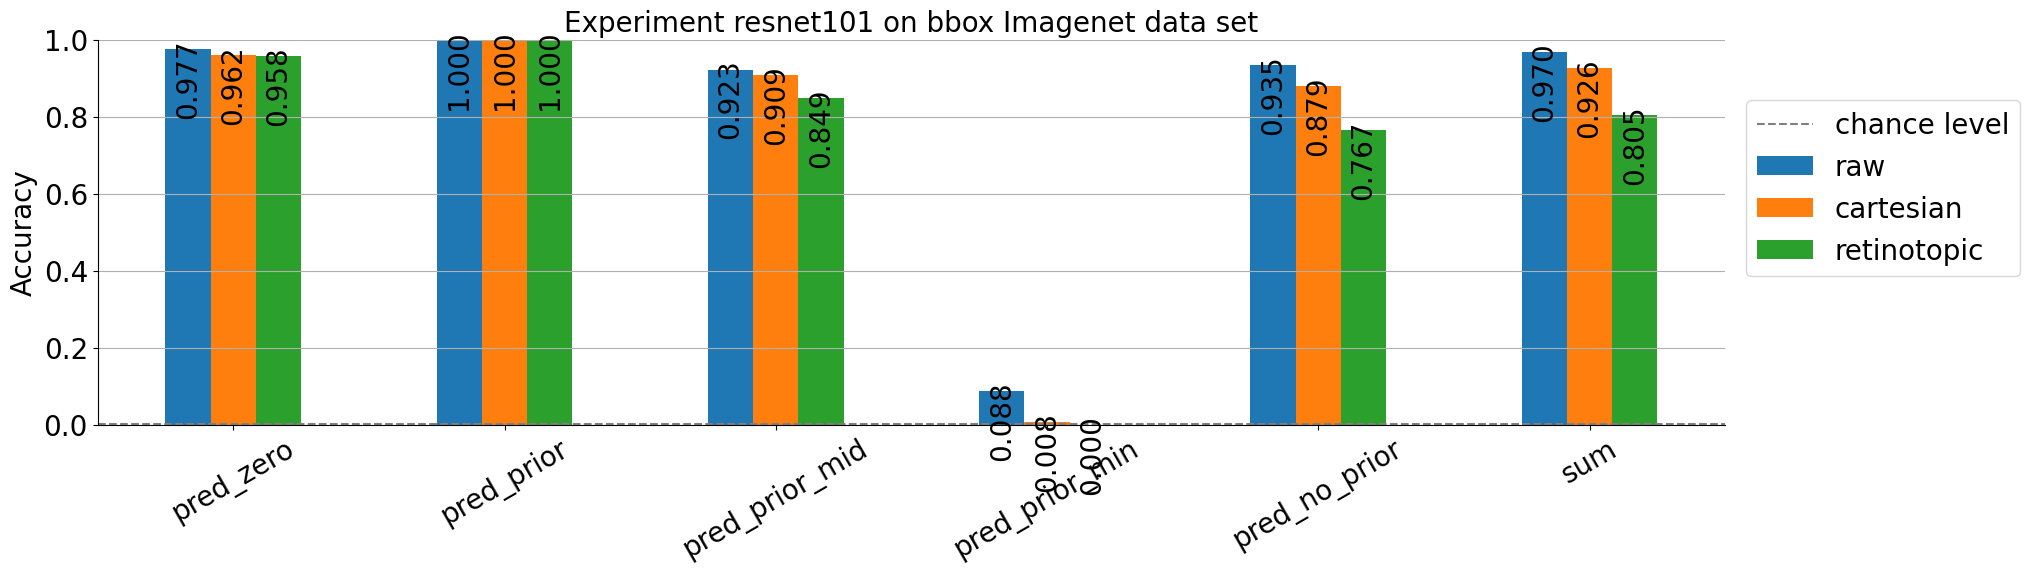

In [4]:
fig_width = 15
fontsize= 20

for model_data_set_type in ['full', 'bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)
                
        df_acc = pd.DataFrame({pred: {label: accuracy_score(df_[pred], np.ones(len(df_)))
                                            for label, df_ in zip(['raw', 'cartesian', 'retinotopic'], [df_raw, df, df_ret])} 
                               for pred in ['pred_zero', 'pred_prior', 'pred_prior_mid', 'pred_prior_min', 'pred_no_prior', 'sum']})
        
        ax = df_acc.T.plot.bar(rot=30, figsize=(fig_width*1.4, fig_width//3), fontsize=fontsize)
        ax.set_ylim(0, 1)
        ax.hlines(xmin=-.5, xmax=7.5, y=1/1000, ls='--', ec='gray', label='chance level')
        # https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
        for container in ax.containers: ax.bar_label(container, padding=-50, color='black', fontsize=fontsize, fmt='%.3f', rotation=90)
        plt.legend(bbox_to_anchor=(1.19, .35), loc='lower right', fontsize=fontsize)
        ax.grid(which='both', axis='y')
        for side in ['top', 'right'] :ax.spines[side].set_visible(False)
        ax.set_title(f'Experiment {model_name} on {model_data_set_type} Imagenet data set', size=fontsize)
        ax.set_ylabel('Accuracy', size=fontsize)
        plt.show();

In [5]:
for model_data_set_type in  data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    

    
    print(50*'-')

    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
    #for model_name in ['resnet18']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [False, True]:
            
            args.do_polar = do_polar
            if do_polar and model_data_set_type =='raw':
                break
                
            print(f'{args.do_polar=}')
            print(50*'.')

            
            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_map_Animal_10k_paper.parquet'
            results = pd.read_parquet(df_filename)
            
            print(results['likelihood_in_mean'].mean(), 'likelihood_in_mean')
            print(results['likelihood_out_mean'].mean(), 'likelihood_out_mean')
            print(results['likelihood_in_mean'].mean()/results['likelihood_out_mean'].mean(), 'likelihood ratio')
            print(results['likelihood_in_max'].mean(), 'likelihood_in_max')
            print(results['likelihood_out_max'].mean(), 'likelihood_out_max')
            
            
            print(results['mid_point'].mean(), 'mid_point')
            print(results['in_point'].mean(), 'in_point')
            print(results['ext_point'].mean(), 'ext_point')
    
            mean_Iou = read_IoU(results['Iou'])
            print(mean_Iou[0], 'mean IoU')

            best_Iou = get_best_Iou(results['Iou'], np.argmax(mean_Iou[0]))
            
            for test_tresh in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
                inpel = 0
                for i, j in enumerate(results['likelihood_in_max']):
                    #print(i, j, results['max_in_heat'][i] , '>', results['max_out_heat'][i])
                    if best_Iou[i] > test_tresh and 1 == results['pred_prior'][i]:
                        inpel += 1
                print(inpel/len(results['likelihood_in_max']), f'GT-known : {test_tresh}')
        
            
            
            print(results['PG'].mean(), 'PG')
        


model_data_set_type='raw'
--------------------------------------------------
model_name='resnet18'
..................................................
args.do_polar=False
..................................................
0.5168755813376235 likelihood_in_mean
0.13357913601405164 likelihood_out_mean
3.869433481612365 likelihood ratio
0.9477275571374374 likelihood_in_max
0.7723871263756761 likelihood_out_max
0.7477835852543308 mid_point
0.18504615244490072 in_point
0.06719663099809671 ext_point
{0: 0.3944248915882404, 1: 0.4444298482654533, 2: 0.4950631618970889, 3: 0.5176412527409753, 4: 0.5271845641005953, 5: 0.5301131415597632, 6: 0.5290500169465214, 7: 0.5259362056616628, 8: 0.52151037754825, 9: 0.5157239160150232, 10: 0.5089514618076354, 11: 0.501604266021841, 12: 0.4938939550958763, 13: 0.4860570557700474, 14: 0.47776777260611325, 15: 0.4691239029690485, 16: 0.4599261914106489, 17: 0.45034597902087004, 18: 0.4407549897475184, 19: 0.43110546314132103, 20: 0.4208873860545021, 21: 0.41

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_Animal_10k_paper.parquet'


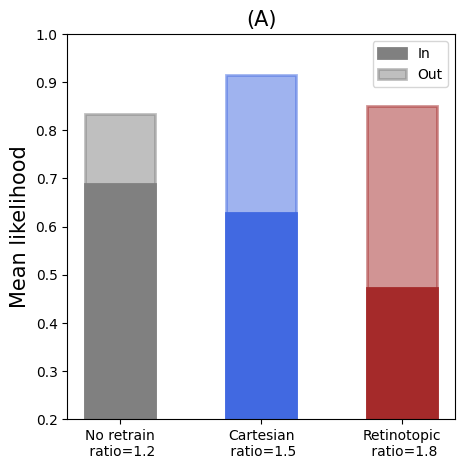

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# data from https://allisonhorst.github.io/palmerpenguins/
 

for model_data_set_type in ['bbox']:
#for model_data_set_type in ['full', 'bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        below, above, ratio = [], [], []
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        for df_ in [df_raw, df, df_ret]:

            below.append(df_['likelihood_out_mean'].mean())
            above.append(df_['likelihood_in_mean'].mean())
            ratio.append(df_['likelihood_in_mean'].mean()/df_['likelihood_out_mean'].mean())

        weight_counts = {
            "In": np.array(below),
            "Out": np.array(above),
        }
        
        species = (
            f"No retrain\n ratio={ratio[0]:.1f}",
            f"Cartesian\n ratio={ratio[1]:.1f}",
            f"Retinotopic\n ratio={ratio[2]:.1f}",
        )
        
        width = 0.5
        
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        bottom = np.zeros(3)
        alpha = 1
        for boolean, weight_count in weight_counts.items():
            p = ax.bar(species, weight_count, width, label=boolean, bottom=bottom, alpha=alpha, color=['grey', 'royalblue', 'brown'],
                       edgecolor =['grey', 'royalblue', 'brown'], linewidth = 2)
            #bottom += weight_count
            alpha -= .5
        
        ax.set_ylim(0.2, 1)
        ax.set_title("Mean likehood for the label of interest")
        ax.legend(loc="upper right")
        ax.set_ylabel(f"Mean likelihood", size=15)
        #ax.set_xlabel(f"Ratio In / Out", size=15)
        #ax.axhline(y=0.5, xmin=0, ls='--', color='black', alpha=.5, xmax=5)
        ax.set_title(f'(A)', size=15);
        plt.show()
        if False:
            to_save(fig, 'fig-animal_ratio_paper')

model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_Animal_10k_paper.parquet'
..................................................
df_filename='cached_data/2024-05-24_full_resnet50_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_Animal_10k_paper.parquet'
..................................................
df_filename='cached_data/2024-05-24_full_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_Animal_10k_paper.parquet'
model_data_set_type

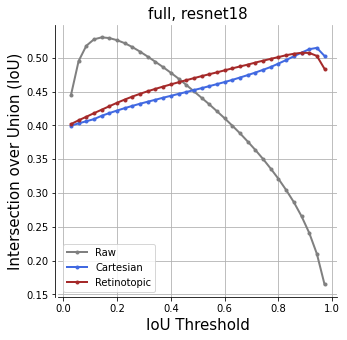

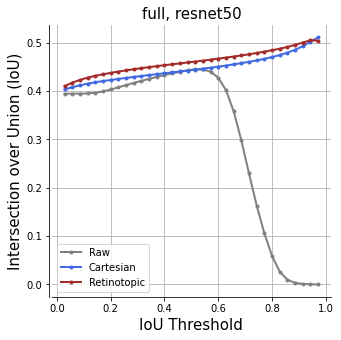

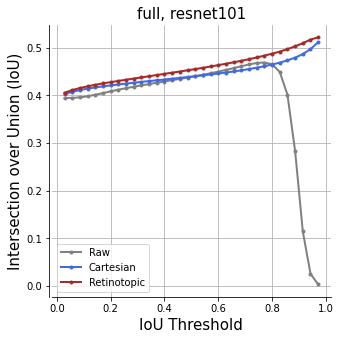

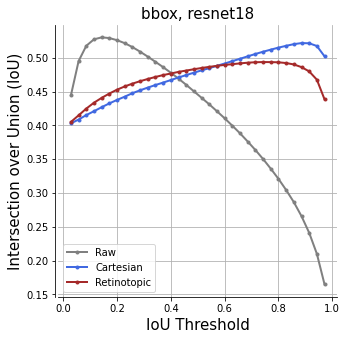

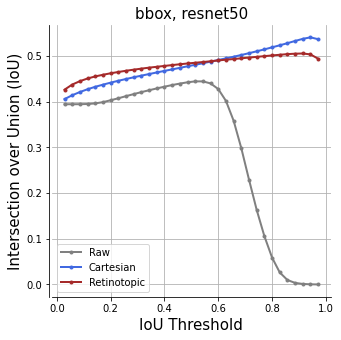

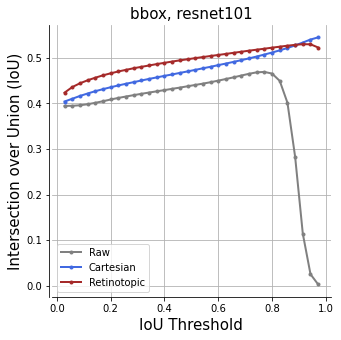

In [7]:
for model_data_set_type in ['full', 'bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)


        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
        
            mean_Iou, list_Iou = read_IoU(df_['Iou'])
        
        
            all_test = np.linspace(0, 1,36)
            ax.plot(all_test[1:-1], list_Iou[1:-1], lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"IoU Threshold", size=15)
            ax.set_ylabel(f"Intersection over Union (IoU)", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
            #ax.set_yscale("logit", one_half="1/2", use_overline=True)
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            ax.set_title(f'{model_data_set_type}, {model_name}', size=15);
            if False:
                to_save(fig, 'fig-IoU_animal_paper')

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_Animal_10k_paper.parquet'


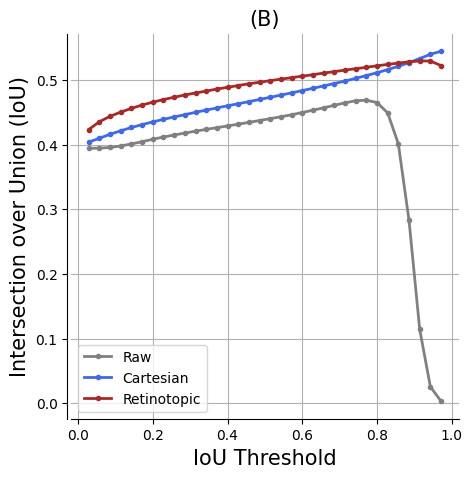

In [17]:
#for model_data_set_type in ['full', 'bbox']:
for model_data_set_type in ['bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)


        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
        
            mean_Iou, list_Iou = read_IoU(df_['Iou'])
        
        
            all_test = np.linspace(0, 1,36)
            ax.plot(all_test[1:-1], list_Iou[1:-1], lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"IoU Threshold", size=15)
            ax.set_ylabel(f"Intersection over Union (IoU)", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
            #ax.set_yscale("logit", one_half="1/2", use_overline=True)
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #ax.set_title(f'{model_data_set_type}, {model_name}', size=15);
            ax.set_title(f'(B)', size=15);
            if False:
                to_save(fig, 'fig-IoU_animal_paper')

df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_Animal_10k_paper.parquet'


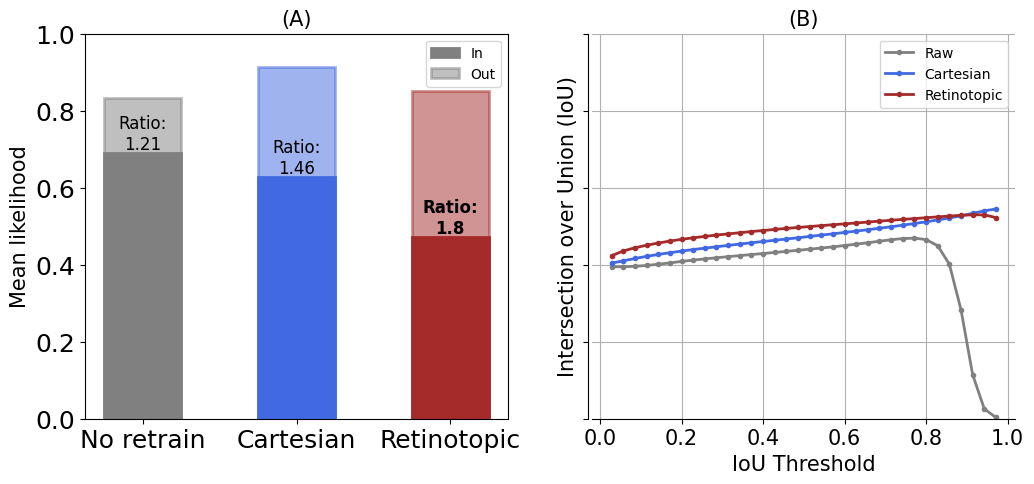

In [83]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 5))

ax = axs[0]

model_data_set_type = 'bbox'
model_name ==  ['resnet101']

below, above, ratio = [], [], []
df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

for df_ in [df_raw, df, df_ret]:

    below.append(df_['likelihood_out_mean'].mean())
    above.append(df_['likelihood_in_mean'].mean())
    ratio.append(df_['likelihood_in_mean'].mean()/df_['likelihood_out_mean'].mean())

weight_counts = {
    "Out": np.array(below),
    "In": np.array(above),
}

species = (
    f"No retrain",#\n ratio={ratio[0]:.1f}",
    f"Cartesian",#\n ratio={ratio[1]:.1f}",
    f"Retinotopic",#\n ratio={ratio[2]:.1f}",
)

width = 0.5

plt.tick_params(axis='both', which='major', labelsize=10)
bottom = np.zeros(3)
alpha = 1
for boolean, weight_count in weight_counts.items():
    p = ax.bar(species, weight_count, width, label=boolean, bottom=bottom, alpha=alpha, color=['grey', 'royalblue', 'brown'],
                edgecolor =['grey', 'royalblue', 'brown'], linewidth = 2)
    alpha -= .5

ax.set_ylim(0, 1)
ax.set_title("Mean likehood for the label of interest")
ax.legend(loc="upper right")
ax.set_ylabel(f"Mean likelihood", size=15)
ax.set_title(f'(A)', size=15);
x_pos = [0, 1, 2]
for i in range(len(species)):
    fontweight = 'bold' if ratio[i] == max(ratio) else 'normal'
    ax.text(x = x_pos[i], y = below[i] + 0.01, s = f"Ratio:\n{round(ratio[i], 2)}", fontsize=12, color='black', ha='center', fontweight=fontweight)

ax = axs[1]

#plt.tick_params(axis='both', which='major', labelsize=10)

for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):

    mean_Iou, list_Iou = read_IoU(df_['Iou'])


    all_test = np.linspace(0, 1,36)
    ax.plot(all_test[1:-1], list_Iou[1:-1], lw=2, marker='.', label=label, color=color)
    ax.set_xlabel(f"IoU Threshold", size=15)
    ax.set_ylabel(f"Intersection over Union (IoU)", size=15)
    ax.spines['left'].set_position(('axes', -0.01))
    #ax.set_yscale("logit", one_half="1/2", use_overline=True)
    ax.grid(which='both')
    ax.legend()
    for side in ['top', 'right'] :ax.spines[side].set_visible(False)
    #ax.set_title(f'{model_data_set_type}, {model_name}', size=15);
    ax.set_title(f'(B)', size=15)
    ax.tick_params(axis='x', labelsize=15)

plt.show()

if True:
    to_save(fig, 'fig-animal_10k_mesure_paper')

In [9]:

df_filename = f"{data_cache}/get_distance_to_plot_animal.parquet"
results = pd.read_parquet(df_filename)

distance_plot = np.concatenate([np.zeros(len(results['Distance_0'])), np.asarray(results['Distance_0']), np.asarray(results['Distance_1'])])
distance_plot = normalize_array(distance_plot)

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_Animal_10k_paper.parquet'


/tmp/ipykernel_2638789/1900766257.py:22: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean())
/home/INT/jeremie.j/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


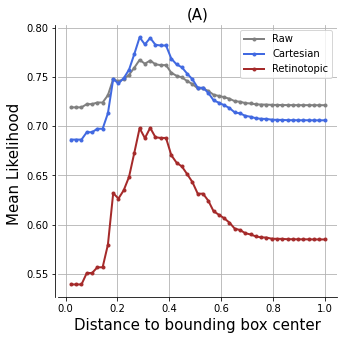

In [21]:
for model_data_set_type in [ 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
            list_dist = []
            
            
            likelihood_plot = np.concatenate([np.array(df_['in_point']), np.array(df_['mid_point']), np.array(df_['ext_point'])])
            
            new_likelihood_plot = []
            for i in np.linspace(0, 1, 50 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean()) 
        
        
        
            ax.plot(np.linspace(0, 1, 50 ), new_likelihood_plot, lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"Distance to bounding box center", size=15)
            ax.set_ylabel(f"Mean Likelihood ", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            ax.set_title(f'(A)', size=15);

                    
        


model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_Animal_10k_paper.parquet'
nan nan
nan nan
nan nan
..................................................
df_filename='cached_data/2024-05-24_full_resnet50_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_map_Animal_10k_paper.parquet'


/tmp/ipykernel_2638789/657731505.py:26: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean())
/home/INT/jeremie.j/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2638789/657731505.py:26: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean())
/home/INT/jeremie.j/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_Animal_10k_paper.parquet'
nan nan
nan nan
nan nan
..................................................
df_filename='cached_data/2024-05-24_full_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_Animal_10k_paper.parquet'


/tmp/ipykernel_2638789/657731505.py:26: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean())
/home/INT/jeremie.j/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2638789/657731505.py:26: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean())
/home/INT/jeremie.j/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


nan nan
nan nan
nan nan
model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet18_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet18_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_Animal_10k_paper.parquet'
nan nan
nan nan
nan nan
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet50_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet50_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_Animal_10k_paper.parquet'
nan nan
nan nan
nan nan
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_r

/tmp/ipykernel_2638789/657731505.py:26: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean())
/home/INT/jeremie.j/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2638789/657731505.py:26: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean())
/home/INT/jeremie.j/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


nan nan
nan nan
nan nan


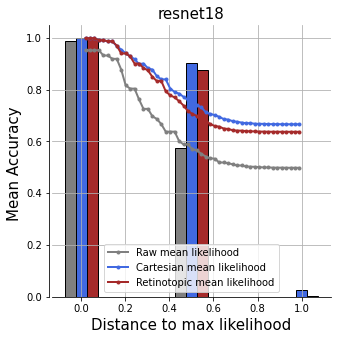

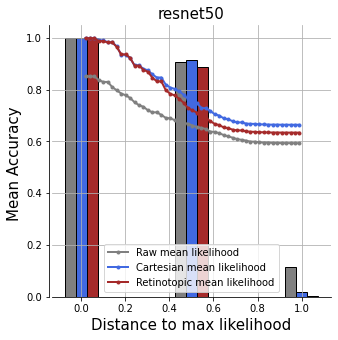

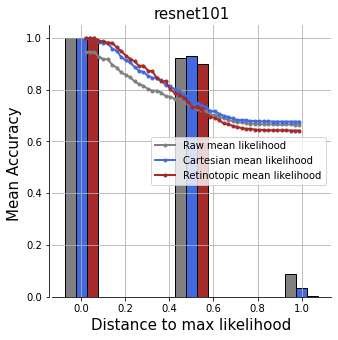

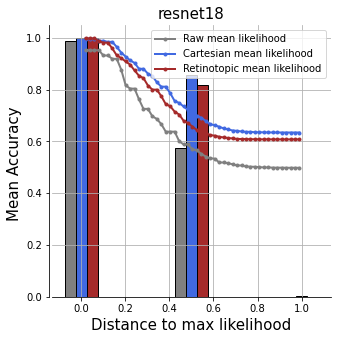

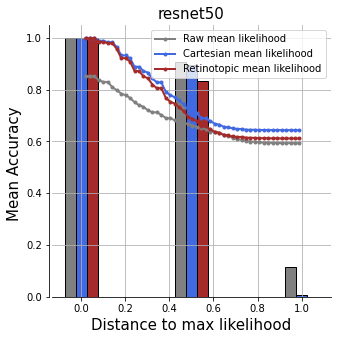

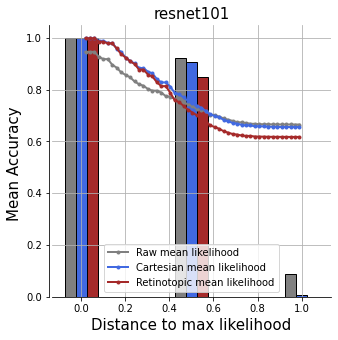

In [20]:
for model_data_set_type in ['full', 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    #for model_name in  ['resnet101']:
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
            
            
            list_dist = []
            
            distance_plot = np.concatenate([np.zeros(len(df_['Distance_0'])), np.asarray(df_['Distance_0']), np.asarray(df_['Distance_1'])])
            distance_plot = normalize_array(distance_plot)
            likelihood_plot = np.concatenate([np.array(df_['likelihood_prior']), np.array(df_['likelihood_prior_mid']),  np.array(df_['likelihood_prior_min'])])

            
            new_likelihood_plot = []
            for i in np.linspace(0, .99, 50 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean()) 
            print(max(new_likelihood_plot), min(new_likelihood_plot))

        
            ax.plot(np.linspace(0, .99, 50 ), new_likelihood_plot, lw=2, marker='.', label=label+' mean likelihood', color = color)
            ax.set_xlabel(f"Distance to max likelihood", size=15)
            ax.set_ylabel(f"Mean Accuracy ", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);
                
        df_acc = pd.DataFrame({pred: {label: accuracy_score(df_[pred], np.ones(len(df_)))
                                            for label, df_ in zip(['raw', 'cartesian', 'retinotopic'], [df_raw, df, df_ret])} 
                               for pred in ['pred_prior', 'pred_prior_mid', 'pred_prior_min']})
    
        ax.set_title(f'{model_name}', size=15);
        N = 3
        ind = np.arange(N)  * 7 
        ind = np.linspace(0,1,N)
        width = 0.05
          
        xvals = np.asarray(df_acc.T['raw'])
        bar1 = plt.bar(ind-width, xvals, width, color = 'gray', edgecolor='black') 
          
        yvals = np.asarray(df_acc.T['cartesian'])
        bar2 = plt.bar(ind, yvals, width, color='royalblue', edgecolor='black')  
          
        zvals = np.asarray(df_acc.T['retinotopic'])
        bar3 = plt.bar(ind+width, zvals, width, color = 'brown', edgecolor='black') 

if False:
    to_save(fig, 'fig-distance_accuracy_paper')

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_Animal_10k_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_Animal_10k_paper.parquet'
nan nan
nan nan
nan nan


/tmp/ipykernel_2638789/2354718823.py:24: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean())
/home/INT/jeremie.j/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


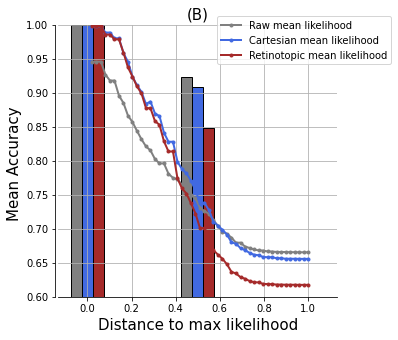

In [19]:
for model_data_set_type in ['bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
            
            
            list_dist = []
            
            distance_plot = np.concatenate([np.zeros(len(df_['Distance_0'])), np.asarray(df_['Distance_0']), np.asarray(df_['Distance_1'])])
            distance_plot = normalize_array(distance_plot)
            likelihood_plot = np.concatenate([np.array(df_['likelihood_prior']), np.array(df_['likelihood_prior_mid']),  np.array(df_['likelihood_prior_min'])])

            
            new_likelihood_plot = []
            for i in np.linspace(0, 1, 50 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot < i)].mean()) 
            print(max(new_likelihood_plot), min(new_likelihood_plot))

        
            ax.plot(np.linspace(0, 1, 50 ), new_likelihood_plot, lw=2, marker='.', label=label+' mean likelihood', color = color)
            ax.set_xlabel(f"Distance to max likelihood", size=15)
            ax.set_ylabel(f"Mean Accuracy ", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend(bbox_to_anchor=(0.55, 1.05))
            
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);
                
        df_acc = pd.DataFrame({pred: {label: accuracy_score(df_[pred], np.ones(len(df_)))
                                            for label, df_ in zip(['raw', 'cartesian', 'retinotopic'], [df_raw, df, df_ret])} 
                               for pred in ['pred_prior', 'pred_prior_mid', 'pred_prior_min']})
    
        ax.set_title(f'(B)', size=15);
        N = 3
        ind = np.arange(N)  * 7 
        ind = np.linspace(0,1,N)
        width = 0.05
          
        xvals = np.asarray(df_acc.T['raw'])
        bar1 = plt.bar(ind-width, xvals, width, color = 'gray', edgecolor='black') 
          
        yvals = np.asarray(df_acc.T['cartesian'])
        bar2 = plt.bar(ind, yvals, width, color='royalblue', edgecolor='black')  
          
        zvals = np.asarray(df_acc.T['retinotopic'])
        bar3 = plt.bar(ind+width, zvals, width, color = 'brown', edgecolor='black') 
ax.set_ylim(0.6, 1)
if False:
    to_save(fig, 'fig-distance_animal_paper')